Feature Matrix Shape with All Interactions: (2442, 336)
Running Final Validated Model...

FINAL MACRO F1 SCORE: 0.7031
                   precision    recall  f1-score   support

          Cycling       0.90      0.93      0.92       274
         Football       0.73      0.86      0.79       387
          Jogging       0.69      0.75      0.72        12
         JumpRope       0.77      0.64      0.70       117
          Pushups       1.00      0.35      0.52        17
          Sitting       0.99      0.99      0.99       696
         Swimming       0.66      0.76      0.71       122
           Tennis       0.79      0.74      0.76       580
          Walking       0.82      0.86      0.84        59
WalkingDownstairs       0.39      0.31      0.35        84
  WalkingUpstairs       0.48      0.39      0.43        94

         accuracy                           0.82      2442
        macro avg       0.75      0.69      0.70      2442
     weighted avg       0.82      0.82      0.82     

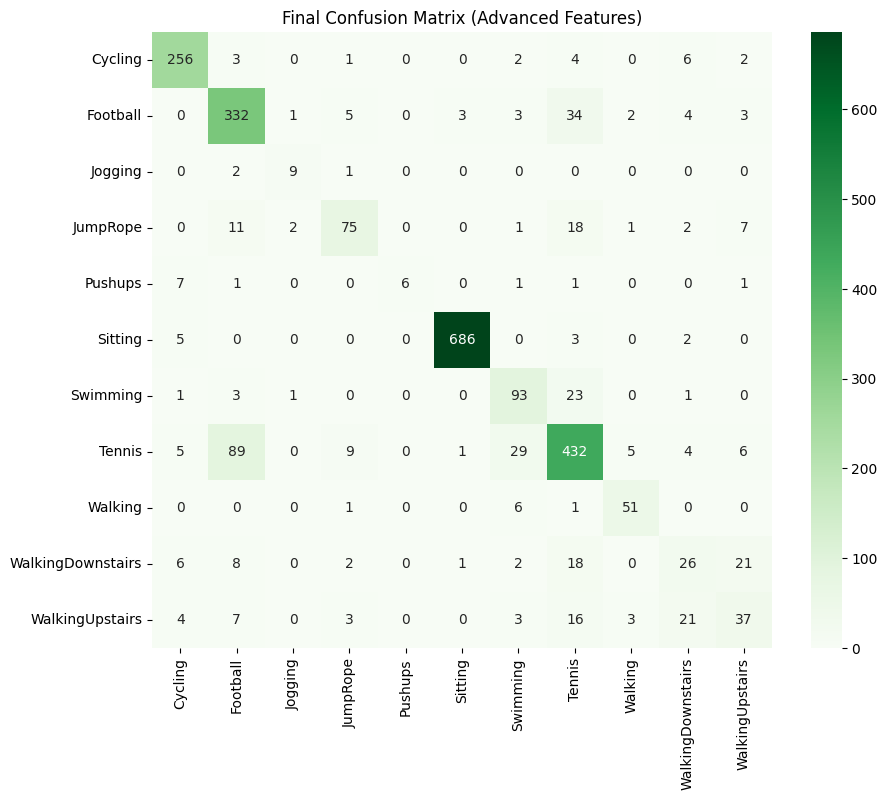

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# --- 1. Load Data ---
df = pd.read_csv('har_train.csv', header=None)
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# --- 2. Advanced Feature Engineering ---

# --- Upstairs vs Walking ---
# Decision Tree found Col 30, Col 66, and Col 31 are key.
X['Walking_Gate_1'] = X[30] * X[66] # Captures the low-intensity split
X['Walking_Gate_2'] = X[30] * X[31] # Captures the high-intensity split

# --- Downstairs vs Walking ---
# Decision Tree found Col 123 is the differentiator.
X['Down_Gate'] = X[30] * X[123]

# --- Up vs Down (Stairs Direction) ---
# Col 7 and Col 132 separate the two stair directions.
X['Stairs_Dir_Gate'] = X[7] * X[132]

# --- Sports (Tennis vs Swimming) ---
# Col 161 and Col 24 (Cycling marker) separate these.
X['Sports_Gate'] = X[161] * X[24]

# --- Ealier HITS ---
X['Jog_Signal'] = X[159] * X[30]
X['Stairs_Ratio'] = X[24] / (X[30].abs() + 0.001)
X['Sitting_Gravity'] = X[6].abs()

# --- Ensuring string names ---
X.columns = X.columns.astype(str)

print(f"Feature Matrix Shape with All Interactions: {X.shape}")

# --- 3. The Validation Pipeline ---
le = LabelEncoder()
y_encoded = le.fit_transform(y)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('model', xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4, 
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softprob',
        random_state=42,
        n_jobs=-1
    ))
])

# --- 4. Execution ---
print("Running Final Validated Model...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_honest = cross_val_predict(pipeline, X, y_encoded, cv=cv, n_jobs=-1)

# Decode
y_true = le.inverse_transform(y_encoded)
y_pred = le.inverse_transform(y_pred_honest)

# --- 5. Final Report ---
print(f"\nFINAL MACRO F1 SCORE: {f1_score(y_true, y_pred, average='macro'):.4f}")
print(classification_report(y_true, y_pred))

# Comparison Plot
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred, labels=le.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Final Confusion Matrix (Advanced Features)')
plt.show()

In [2]:
import pickle
def train_and_save():
    # 1. Load Data
    print("Loading data...")
    df = pd.read_csv('har_train.csv', header=None)
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

    # 2. Feature Engineering Logic (Must match prediction script!)
    def add_features(X_input):
        X_feat = X_input.copy()
        # Ensure string column names for XGBoost
        X_feat.columns = X_feat.columns.astype(str)
        
        # Physics-based interaction features
        X_feat['Walking_Gate_1'] = X_feat['30'] * X_feat['66']
        X_feat['Walking_Gate_2'] = X_feat['30'] * X_feat['31']
        X_feat['Down_Gate'] = X_feat['30'] * X_feat['123']
        X_feat['Stairs_Dir_Gate'] = X_feat['7'] * X_feat['132']
        X_feat['Sports_Gate'] = X_feat['161'] * X_feat['24']
        X_feat['Jog_Signal'] = X_feat['159'] * X_feat['30']
        # Add epsilon to avoid division by zero
        X_feat['Stairs_Ratio'] = X_feat['24'] / (X_feat['30'].abs() + 0.001)
        X_feat['Sitting_Gravity'] = X_feat['6'].abs()
        
        return X_feat

    print("Applying feature engineering...")
    X_eng = add_features(X)

    # 3. Encode Labels
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    # 4. Pipeline
    
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42, k_neighbors=3)),
        ('model', xgb.XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            objective='multi:softprob',
            random_state=42,
            n_jobs=-1
        ))
    ])

    # 5. Train on FULL dataset
    print("Training final model on full dataset...")
    pipeline.fit(X_eng, y_encoded)

    # 6. Export
    print("Exporting models...")
    with open('task2_model.pkl', 'wb') as f:
        pickle.dump(pipeline, f)
    
    with open('task2_le.pkl', 'wb') as f:
        pickle.dump(le, f)
        
    print("Done! Files 'task2_model.pkl' and 'task2_le.pkl' created.")

if __name__ == "__main__":
    train_and_save()

Loading data...
Applying feature engineering...
Training final model on full dataset...
Exporting models...
Done! Files 'task2_model.pkl' and 'task2_le.pkl' created.
